# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Cargue el archivo de datos, y haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

In [2]:
import pandas as pd 
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "data talleres"
file_name = "Telco_customer_churn.csv"
file_path = DATA_DIR / file_name

df = pd.read_csv(file_path, na_values= '?')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
# Cuantitativas
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


* La variable **Count** toma un solo valor
* La varibale **Churn value** es cualitativa porque solo toma dos valores (0 y 1)

In [5]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


* **CustomerID** es una clave primaria
* **Country** y **State** tienen valores únicos
* **Churn value** es la misma variable objetivo pero codificada de diferente manera
* **Churn Score** es un puntaje asignado para medir probabilidad de abandono, si lo incluimos genera una dependencia circular
* **Lat Long** es la concatenación de latitude y longitude


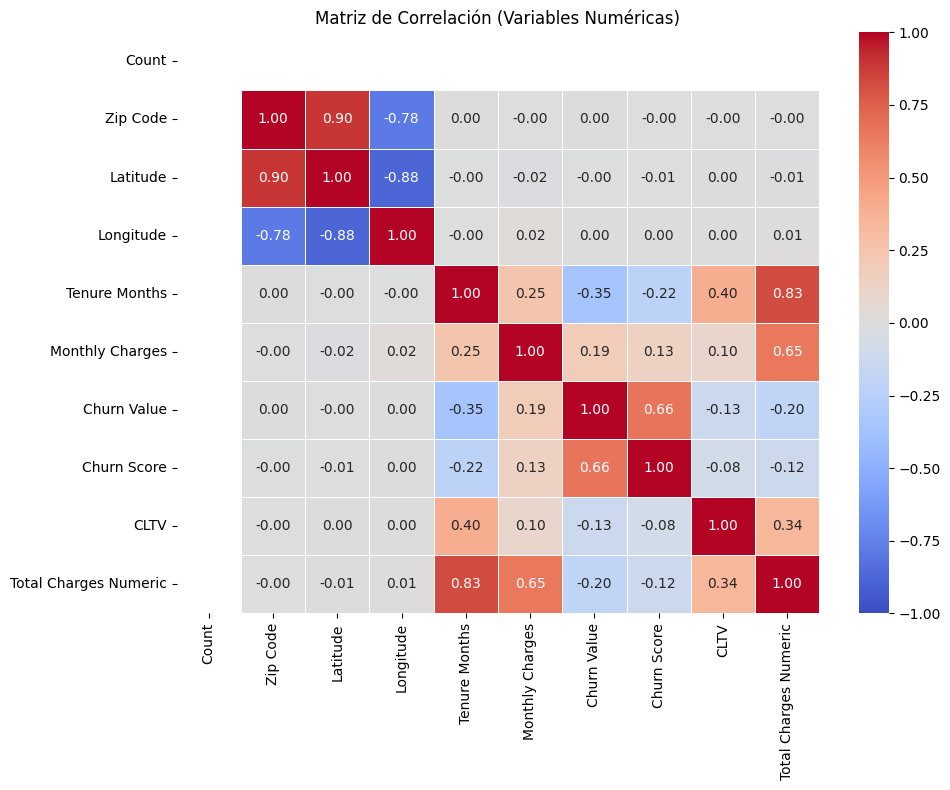

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


df['Total Charges Numeric'] = pd.to_numeric(df['Total Charges'].astype(str).str.strip(), errors='coerce')

corr_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación (Variables Numéricas)')
plt.tight_layout()
plt.show()


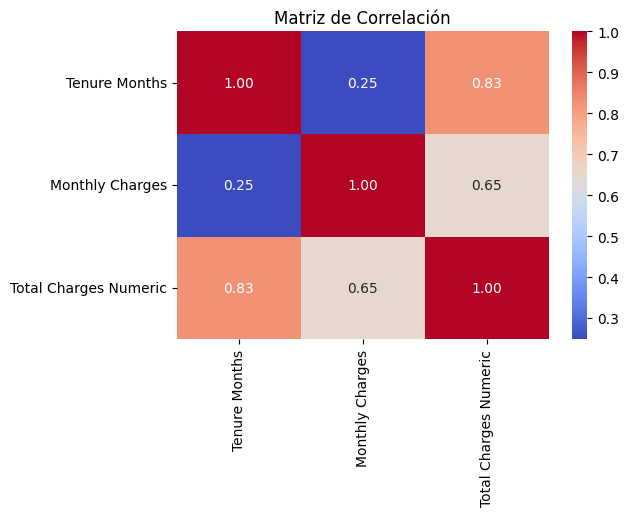

In [11]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges Numeric']
corr_matrix = df[num_cols].corr()


plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

* **Total Charges** presenta una correlación muy fuerte con **Tenure Months** y **Monthly Charges**, tiene una redundancia matemática.

In [6]:
leakage_check = df.groupby('Churn Label')['Churn Reason'].apply(lambda x: x.notnull().mean() * 100)
print(leakage_check)

Churn Label
No       0.0
Yes    100.0
Name: Churn Reason, dtype: float64


* **Churn Reason** tiene riesgo de filtración porque solo registra valor cuando el cliente ya canceló, los clientes activos  tienen este capo en null en todos los casos

In [15]:
cols_to_drop = ['Churn Value', 'Churn Reason', 'Churn Score','Count', 'Country', 'State','CustomerID', 'Lat Long', 'Total Charges', 'Total Charges Numeric']

df = df.drop(columns=cols_to_drop)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   object 
 10  Multiple Lines     7043 non-null   object 
 11  Internet Service   7043 non-null   object 
 12  Online Security    7043 non-null   object 
 13  Online Backup      7043 non-null   object 
 14  Device Protection  7043 non-null   object 
 15  Tech Support       7043 non-null   object 
 16  Streaming TV       7043 

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [17]:
df.describe(include='object').T

,count,unique,top,freq
City,7043,1129,Los Angeles,305
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361
Multiple Lines,7043,3,No,3390
Internet Service,7043,3,Fiber optic,3096
Online Security,7043,3,No,3498
Online Backup,7043,3,No,3088


**Variables nominales:**
  - Gender
  - Senior Citizen
  - Partner
  - Dependents
  - Phone Service
  - Multiple Lines
  - Internet Service
  - Online Security
  - Online Backup
  - Device Protection
  - Tech Support
  - Streaming TV
  - Streaming Movies
  - Paperless billing
  - Payment Method

**Variables Ordinales:**
  - Contract

**Alta cardinalidad:**
  - City
  - Zip Code

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Reporte los resultados del análisis en una celda de texto.

In [18]:
df.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,1183.057152
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,2003.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,3469.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,4527.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,5380.500000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,6500.000000


array([[<Axes: title={'center': 'Zip Code'}>,
        <Axes: title={'center': 'Latitude'}>],
       [<Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'Tenure Months'}>],
       [<Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'CLTV'}>]], dtype=object)

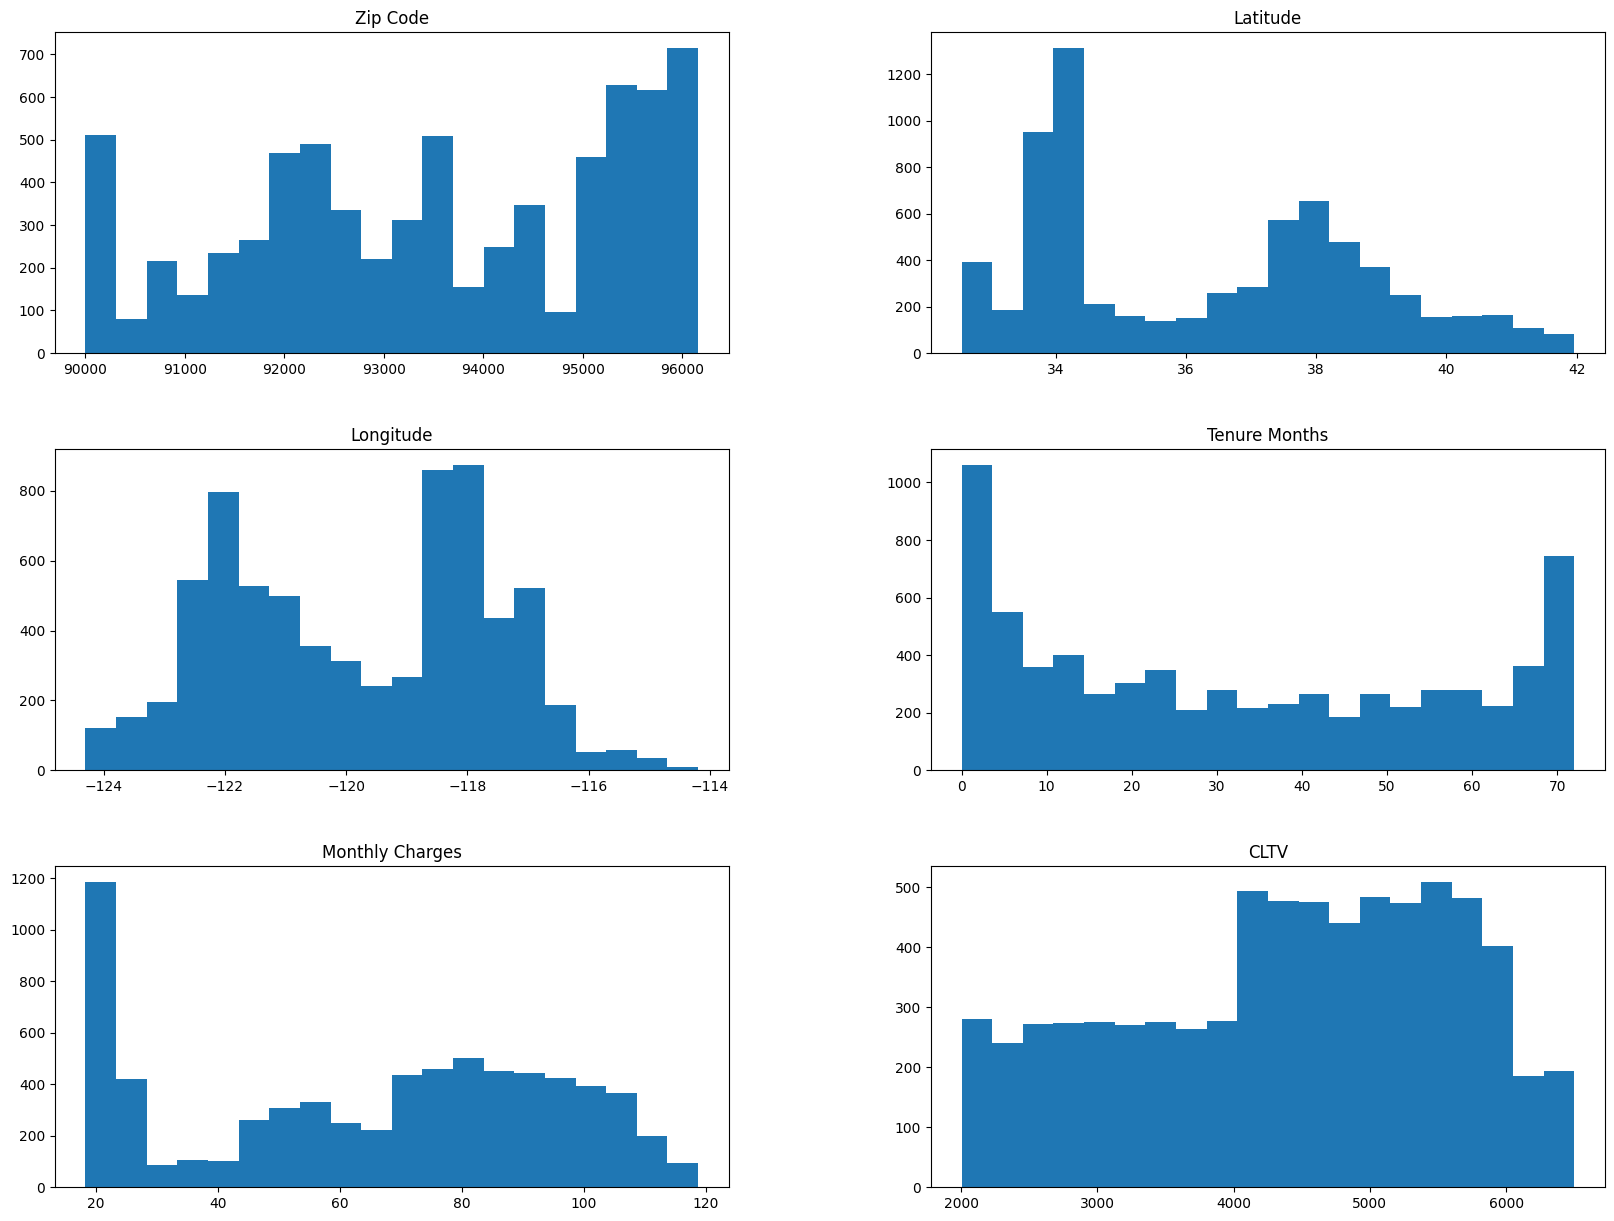

In [19]:
df.hist(
    figsize=(20, 15),
    bins=20,
    grid=False
    )

Con las gráficas no podemos asumir normalidad así que vamos a hacer una prueba de bondad de ajuste

In [20]:
from scipy.stats import kstest

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Zip Code:
  Valor p: 4.349499185284863e-89
  Zip Code no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Latitude:
  Valor p: 7.384987152439983e-206
  Latitude no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Longitude:
  Valor p: 1.9882961763379662e-110
  Longitude no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Tenure Months:
  Valor p: 4.662721654217928e-76
  Tenure Months no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Monthly Charges:
  Valor p: 3.1510583248297797e-98
  Monthly Charges no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para CLTV:
  Valor p: 2.6057958046975655e-23
  CLTV no parece ser normal (se rechaza la hipótesis nula)



**Ninguna** variable es normal

Zip Code              Axes(0.125,0.653529;0.227941x0.226471)
Latitude           Axes(0.398529,0.653529;0.227941x0.226471)
Longitude          Axes(0.672059,0.653529;0.227941x0.226471)
Tenure Months         Axes(0.125,0.381765;0.227941x0.226471)
Monthly Charges    Axes(0.398529,0.381765;0.227941x0.226471)
CLTV               Axes(0.672059,0.381765;0.227941x0.226471)
dtype: object

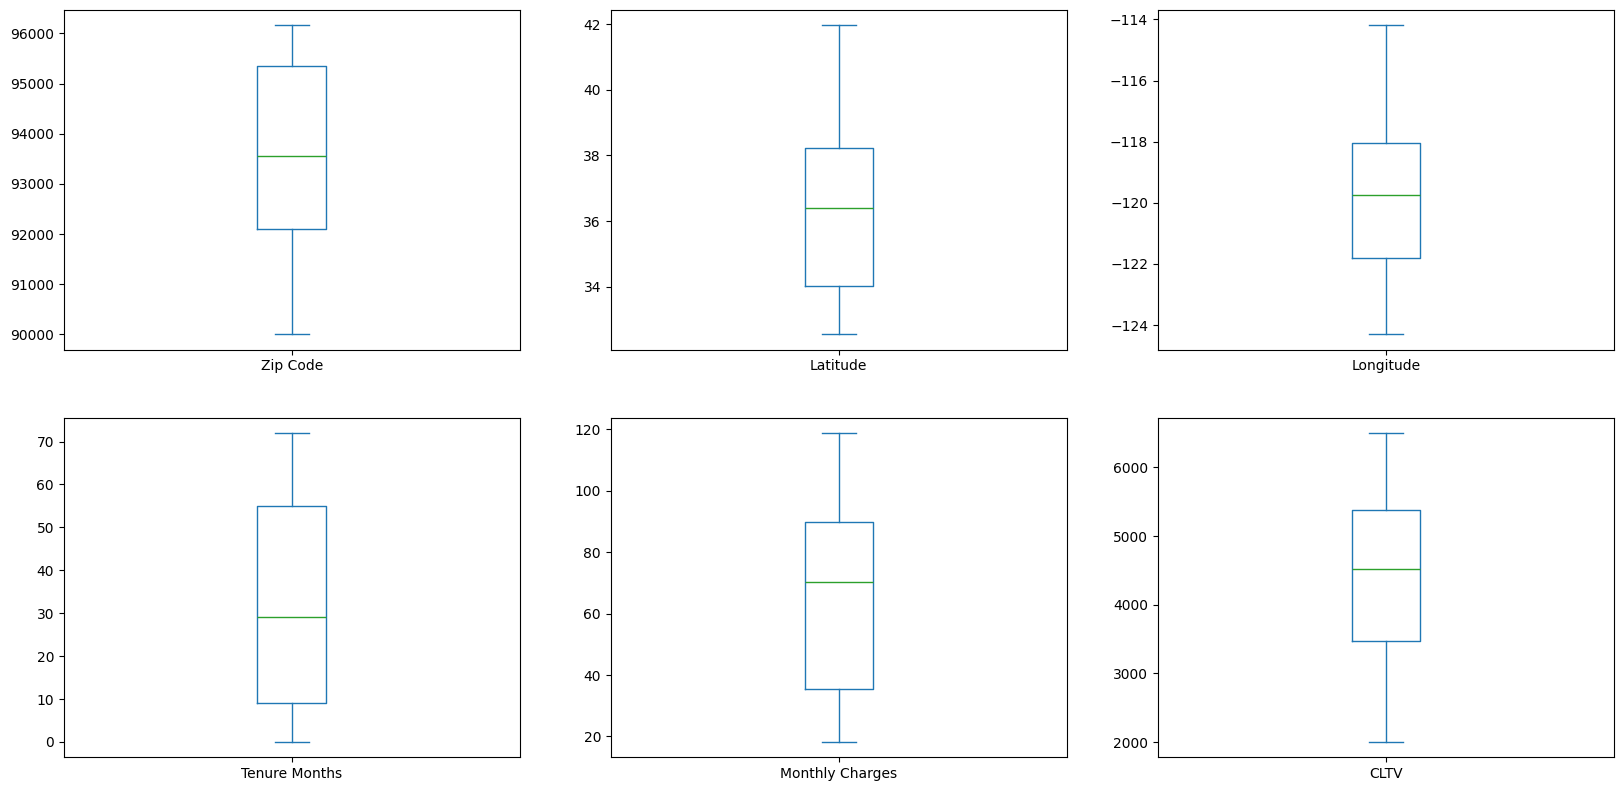

In [21]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

**Ninguna** variable tiene datos atípicos

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Churn Label**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 6 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 6 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [24]:
from sklearn.model_selection import train_test_split

#X tiene todas las variables menos la que quiero predecir 'income'
X = df.drop(
    ['Churn Label'],
    axis=1
    )

#Variable que quiero predecir
y = df['Churn Label']

#Parto el dataframe en datos de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (5634, 23)
Tamaño del conjunto de prueba es: (1409, 23)


In [25]:
X_train

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,CLTV
1814,El Monte,91732,34.074492,-118.014620,Female,No,No,No,37,Yes,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),101.90,4437
5946,Tustin,92780,33.735802,-117.818805,Male,No,Yes,Yes,68,No,...,Yes,No,No,Yes,No,One year,No,Mailed check,44.80,4112
3881,Woodacre,94973,38.005839,-122.638155,Male,No,Yes,Yes,62,Yes,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.95,4803
2389,Woody,93287,35.710244,-118.881679,Female,No,Yes,No,1,Yes,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.65,4517
3676,Clovis,93611,36.917652,-119.593757,Female,Yes,No,No,2,Yes,...,No,No,No,Yes,No,Month-to-month,No,Mailed check,81.50,4267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,Long Beach,90814,33.771612,-118.143866,Male,No,No,No,7,Yes,...,No,No,No,No,Yes,Month-to-month,Yes,Mailed check,85.20,3905
5192,Le Grand,95333,37.249377,-120.249581,Male,No,No,No,37,Yes,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.15,4422
3980,Manteca,95336,37.830267,-121.201018,Male,No,Yes,Yes,42,Yes,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,3433
235,San Francisco,94131,37.746699,-122.442833,Female,No,No,No,13,Yes,...,Yes,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.15,4806


In [36]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

mm = MinMaxScaler() # Para preprocesar Tenure Months, Monthly Charges, CLTV
orden = ['Month-to-month', 'One year', 'Two year']
ore = OrdinalEncoder(categories=[orden], dtype='int') # Para preprocesar Contract
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') # Para preprocesar Internet Service, Tech Support

In [37]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('tenure_monthly_CLTV', mm, ['Tenure Months', 'Monthly Charges', 'CLTV']),
    ('contract', ore, ['Contract']),
    ('internet_support', ohe, ['Internet Service', 'Tech Support'])
    ],
    remainder='drop') # El resto de las características se descartan

preprocessor

,transformers,"[('tenure_monthly_CLTV', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
    ])

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tenure_monthly_CLTV', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tenure_monthly_CLTV', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.7900248491302805
Exactitud del modelo en el conjunto de prueba: 0.7885024840312278


In [ ]:
#Características
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['tenure_monthly_CLTV__Tenure Months',
       'tenure_monthly_CLTV__Monthly Charges',
       'tenure_monthly_CLTV__CLTV', 'contract__Contract',
       'internet_support__Internet Service_DSL',
       'internet_support__Internet Service_Fiber optic',
       'internet_support__Internet Service_No',
       'internet_support__Tech Support_No',
       'internet_support__Tech Support_No internet service',
       'internet_support__Tech Support_Yes'], dtype=object)

Vuelva a entrenar el modelo, pero esta vez añada 3 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [44]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

mm = MinMaxScaler() 
orden = ['Month-to-month', 'One year', 'Two year']
ore = OrdinalEncoder(categories=[orden], dtype='int') 
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') 

In [45]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('tenure_monthly_CLTV', mm, ['Tenure Months', 'Monthly Charges', 'CLTV']),
    ('contract', ore, ['Contract']),
    ('internet_support_gender', ohe, ['Internet Service', 'Tech Support', 'Gender', 'Paperless Billing', 'Payment Method'])
    ],
    remainder='drop') # El resto de las características se descartan

preprocessor

,transformers,"[('tenure_monthly_CLTV', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
    ])

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tenure_monthly_CLTV', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tenure_monthly_CLTV', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.7978345757898474
Exactitud del modelo en el conjunto de prueba: 0.794889992902768


In [ ]:
#Características
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['tenure_monthly_CLTV__Tenure Months',
       'tenure_monthly_CLTV__Monthly Charges',
       'tenure_monthly_CLTV__CLTV', 'contract__Contract',
       'internet_support_gender__Internet Service_DSL',
       'internet_support_gender__Internet Service_Fiber optic',
       'internet_support_gender__Internet Service_No',
       'internet_support_gender__Tech Support_No',
       'internet_support_gender__Tech Support_No internet service',
       'internet_support_gender__Tech Support_Yes',
       'internet_support_gender__Gender_Male',
       'internet_support_gender__Paperless Billing_Yes',
       'internet_support_gender__Payment Method_Bank transfer (automatic)',
       'internet_support_gender__Payment Method_Credit card (automatic)',
       'internet_support_gender__Payment Method_Electronic check',
       'internet_support_gender__Payment Method_Mailed check'],
      dtype=object)